# IMDb Exercise

Let's import a well-structured database, with several tables and relationships, to be used as a sandbox for further exercises on queries.

The database is freely available and is taken from the IMDb (Internet Movie Database) website (https://www.imdb.com/interfaces/), although severely slimmed down.

This database contains several tables with information about movies, TV shows, people involved in the entertainment industry, and more, spanning from the 1890s to recent years.

To simplify the execution of queries, we will work with a slimmed-down version of the entire database, with still plenty of records for us to extract interesting information.

To start working with the IMDb database, we need to import it into our environment. The database `.sql` file should be downloaded from the link on Moodle and copied into the `/mysql/dbs` folder of the GitHub repository so that it will be found in the mounted volume at the location: `/mapd-workspace/dbs/IMDb_pruned.sql`.

1. Create a new DB named `IMDb`
2. Import the content of the file `/mapd-workspace/dbs/IMDb_pruned.sql` into the newly created DB
(this might take a minute or two...)
3. Check which tables are available
4. Describe the content of table Names

In [1]:
%%bash
pwd
cd ..
cd dbs
ls

/mapd-workspace/notebooks
IMDb_pruned.sql
db_dump.sql
world.sql


In [2]:
%load_ext sql
%env DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

env: DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db


In [3]:
%%sql
SHOW DATABASES;

5 rows affected.


Database
IMDb
information_schema
mysql
performance_schema
sys


In [3]:
%%sql
USE IMDb;
SHOW TABLES;

0 rows affected.
7 rows affected.


Tables_in_IMDb
Directors
Episode_belongs_to
Had_role
Names_
Title_genres
Title_ratings
Titles


### Study the distribution of the year of birth of all people included in the database

1. Start by limiting the query to 1000 entries

   A. Draw a histogram of the year of birth
   
   B. Draw a second histogram with the year of birth of the 1000 youngest people in the list

 * mysql+mysqlconnector://root:***@db
1000 rows affected.


Text(0, 0.5, 'counts (query limited to first 1000 entries)')

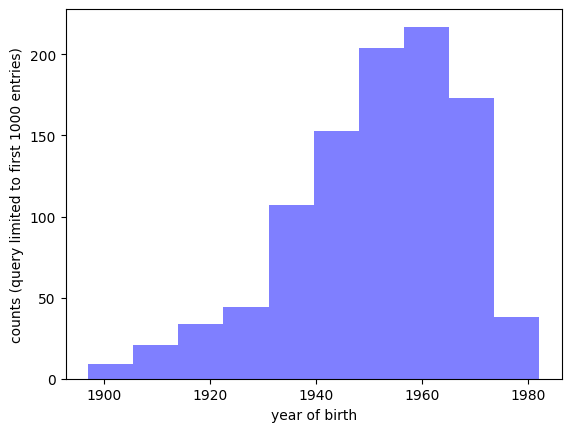

In [4]:
# 1.A
import matplotlib.pyplot as plt
import numpy as np
res_ = %sql SELECT birth_year FROM Names_ LIMIT 1000;
counts, bins = np.histogram(res_)
plt.stairs(counts, bins, fill=True, color = "blue", alpha=0.5)
plt.xlabel("year of birth")
plt.ylabel("counts (query limited to first 1000 entries)")

 * mysql+mysqlconnector://root:***@db
1000 rows affected.


Text(0, 0.5, 'counts')

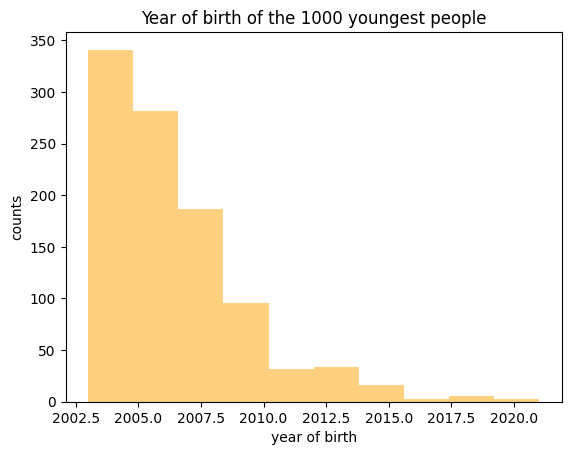

In [5]:
# 1.B
res_ = %sql SELECT birth_year FROM Names_ ORDER BY birth_year DESC LIMIT 1000;
counts, bins = np.histogram(res_)
plt.stairs(counts, bins, fill=True, color = "orange", alpha=0.5)
plt.title("Year of birth of the 1000 youngest people")
plt.xlabel("year of birth")
plt.ylabel("counts")

2. Extend the query to all records in the table
    1. Check for outliers (inspect min and max)
    2. If any outlier is found, limit the query to a reasonable range (say... at least people born after 1850)
    3. Draw a new histogram with the year of birth
    4. Compute the mean and standard deviation of the year of birth

In [6]:
# 2.A
min = %sql SELECT MIN(birth_year) FROM Names_;
max = %sql SELECT MAX(birth_year) FROM Names_;

print(min, max)

 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
+-----------------+
| MIN(birth_year) |
+-----------------+
|        13       |
+-----------------+ +-----------------+
| MAX(birth_year) |
+-----------------+
|       2021      |
+-----------------+


In [7]:
# 2.B
res_ = %sql SELECT birth_year FROM Names_ WHERE birth_year BETWEEN 1850 AND 2025;

 * mysql+mysqlconnector://root:***@db
156309 rows affected.


Text(0, 0.5, 'counts')

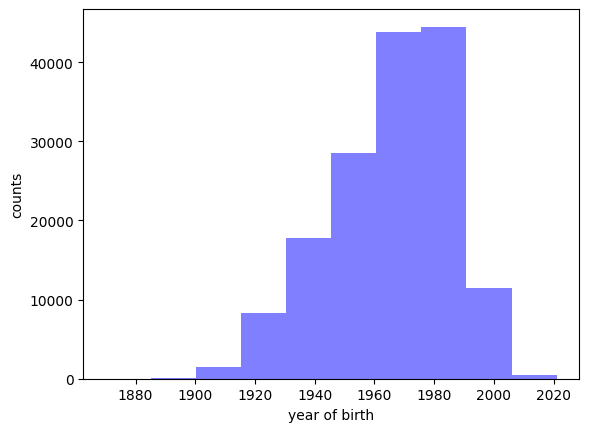

In [8]:
# 2.C
counts, bins = np.histogram(res_)
plt.stairs(counts, bins, fill=True, color = "blue", alpha=0.5)
plt.xlabel("year of birth")
plt.ylabel("counts")

In [9]:
# 2.D
mean = np.mean(res_)
std = np.std(res_)
print(mean, std)

1965.451343172818 19.992053131803555


### Movie stats

1. Plot the number of titles available in the database for each year over the past 25 years.
2. List the names of all actors who have portrayed the character Spider-Man in movies, along with the corresponding movie titles.
3.  List and count the top 10 people who have appeared the most in movies directed by Wes Anderson.

 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+mysqlconnector://root:***@db
1 rows affected.
 * mysql+m

Text(0, 0.5, 'number of titles')

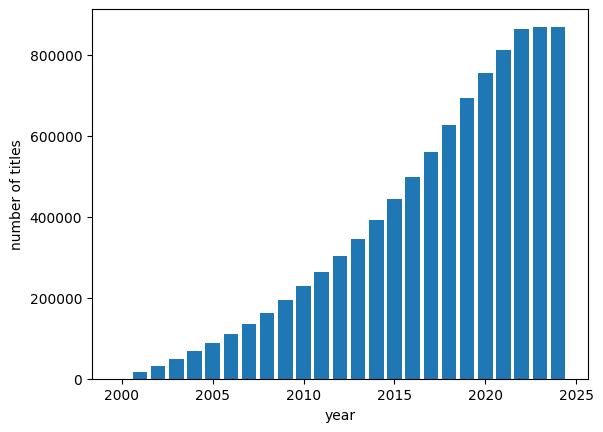

In [10]:
number_of_titles = np.zeros(25) # from 2000 to 2024, included
for i,year in enumerate(np.arange(2000,2025)):
    query = f"SELECT COUNT(DISTINCT title_id) FROM Titles WHERE start_year = {year};"
    result = %sql $query
    number_of_titles[i] = result[0][0]

cumulative_number_of_titles = [np.sum(number_of_titles[0:i]) for i,_ in enumerate(np.arange(2000,2025))] 
plt.bar(np.arange(2000,2025), cumulative_number_of_titles)
plt.xlabel("year")
plt.ylabel("number of titles")

In [11]:
%%sql

SELECT DISTINCT roles_table.role_, actor_table.name_, movie_table.primary_title
FROM Had_role roles_table
LEFT JOIN Names_ actor_table ON (roles_table.name_id = actor_table.name_id)
LEFT JOIN Titles movie_table ON (roles_table.title_id = movie_table.title_id)
WHERE (roles_table.role_ LIKE '%Spiderman%')
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


role_,name_,primary_title
Spiderman Movie Voice,Tress MacNeille,The Pitts
Spiderman #3,Shane Arenal,Only in America
Spiderman,None,Clement direkte med Clement Kjersgaard
Black Spiderman,None,Spiderman Easter Special
Spiderman,None,Zavrsnica Sabornica
Spiderman,None,The Greatest Fan Film of All Time
Spiderman,None,Supers contra Aliens
Spiderman (Spin),None,A Helping Hulk
Spiderman,None,The Elem3ntalist
Spiderman,Saba,The Cure - LULLABY - Cover - FrenchSABA Ep 35


In [3]:
%%sql
SELECT COUNT(t.primary_title) AS NMovies, n.name_
FROM Titles t
INNER JOIN Directors d ON t.title_id = d.title_id
INNER JOIN Had_role r ON t.title_id = r.title_id
LEFT JOIN Names_ n ON n.name_id = r.name_id
WHERE d.name_id = "nm0027572"
GROUP BY n.name_
ORDER BY NMovies DESC
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


NMovies,name_
4,Bill Murray
3,Adrien Brody
3,Owen Wilson
3,Jason Schwartzman
2,Anjelica Huston
1,George Clooney
1,Bruce Willis
1,Cate Blanchett
1,Bryan Cranston
1,Kara Hayward


### Is IMDB only about movies?
1. Check the number of different media types contained in the database
1. Plot a histogram summarizing the number of titles per media type
1. Find the name and rating of the oldest videogame stored in the database

 * mysql+mysqlconnector://root:***@db
5 rows affected.
 * mysql+mysqlconnector://root:***@db
5 rows affected.
unique media types = 5


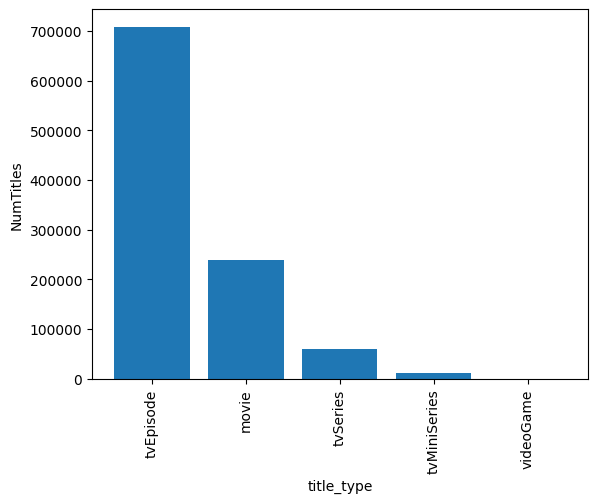

In [5]:
res_ = %sql SELECT title_type, COUNT(title_id) AS NumTitles FROM Titles GROUP BY title_type ORDER BY NumTitles DESC;
import matplotlib.pyplot as plt          
res_.bar()
plt.xticks(rotation = "vertical")

unique_media_types = %sql SELECT DISTINCT title_type FROM Titles;
print("unique media types =", len(unique_media_types))

In [6]:
%%sql
SELECT t.primary_title, t.start_year, r.average_rating
FROM Titles t
LEFT JOIN Title_ratings r ON r.title_id = t.title_id
WHERE t.title_type = "videoGame"
ORDER BY t.start_year
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


primary_title,start_year,average_rating
Lord of the Rings,1990,6.9
Four Million Memories: The 1991 Toronto Blue Jays Highlight Video,1991,None
The Simpsons,1991,8.4
Pacific Islands,1992,None
Rap Rat,1992,None
Garth Brooks: We Shall Be Free,1992,None
Girl's Club,1992,None
B-17 Flying Fortress,1992,None
BlaZeon,1992,None
Shogun Warriors,1992,None


### Identify interesting outliers 

1. List the names of all movies whose titles begin with "The" and have a runtime between 3 and 4 hours.
2. What actor had the most roles as 'Self'?
3. Identify what TV series had more than 1,000 episodes, and identify in what year it was aired the first- and last-episode

In [ ]:
%%sql
SELECT DISTINCT t.primary_title, t.runtime_minutes
FROM Titles t
WHERE (t.primary_title LIKE 'The%') AND (t.runtime_minutes BETWEEN 180 AND 240);

In [5]:
%%sql
SELECT a.name_, COUNT(m.primary_title) AS NumMovies
FROM Names_ a
LEFT JOIN Had_role r ON (r.name_id = a.name_id) AND r.role_ IN ('Himself', 'Herself')
LEFT JOIN Titles m ON (m.title_id = r.title_id)
GROUP BY a.name_
ORDER BY NumMovies DESC
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


name_,NumMovies
Saba,24
Tom Segura,15
Mauro Ranallo,10
Kira Soltanovich,9
Tony Chimel,7
Rufus Hound,4
David Batra,4
Andreas Vitásek,3
José María Calleja,3
Kim Coles,3


In [23]:
%%sql


SELECT t.primary_title, t.start_year, filtered_tvSeries.max_episode
FROM Titles t
RIGHT JOIN (
    SELECT e.parent_tv_show_title_id, MAX(e.episode_number) AS max_episode, COUNT(e.episode_number) AS tot_episode
    FROM Episode_belongs_to e
    GROUP BY e.parent_tv_show_title_id
    HAVING COUNT(e.episode_number) > 1000 AND ( (MAX(e.episode_number)- COUNT(e.episode_number)) BETWEEN -100 AND +100 )
    ORDER BY tot_episode DESC
    LIMIT 20) AS filtered_tvSeries  
ON t.title_id = filtered_tvSeries.parent_tv_show_title_id
ORDER BY filtered_tvSeries.max_episode DESC;

 * mysql+mysqlconnector://root:***@db
20 rows affected.


primary_title,start_year,max_episode
"Gute Zeiten, schlechte Zeiten",1992,7448
Unter uns,1994,6803
Verbotene Liebe,1995,4664
Bom Dia & Cia,1993,4500
Jóban rosszban,2005,4247
Secret Lives,1999,4154
Marienhof,1992,4053
Alles was zählt,2006,3879
Storm of Love,2005,3772
Yeh Rishta Kya Kehlata Hai,2009,3646


### It's all about the ratings 

1. Group all movies by decade and plot their overall rating distribution trend. Limit the query to the movies with at least 1000 ratings.
2. Plot the average rating of each episode of "Games of Thrones". Group by season and compute the average and standard deviation for each season
3. Plot the total number of movies produced per year, divided by genre (Action, Comedy, Drama, Thriller, Fantasy), and the yearly rating average per genre

In [32]:
%%sql
query = 
        SELECT t.primary_title, t.start_year, r.average_rating, r.num_votes
        FROM Titles t
        INNER JOIN Title_ratings r ON t.title_id = r.title_id
        WHERE r.num_votes > 1000 AND t.title_type = "movie"
        ORDER BY r.average_rating DESC
        LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


primary_title,start_year,average_rating,num_votes
The Silence of Swastika,2021,9.9,5013
Jayanti,2021,9.8,1601
Oru Canadian Diary,2021,9.5,4428
Veyi Subhamulu Kalugu Neeku,2022,9.5,2074
Nayeem Diaries,2021,9.5,1081
Hulchul,2020,9.5,1187
Methagu,2021,9.5,8646
Bullet Satyam,2021,9.3,1018
Thirimali,2022,9.3,1104
The Shawshank Redemption,1994,9.3,2545609


 * mysql+mysqlconnector://root:***@db
56 rows affected.


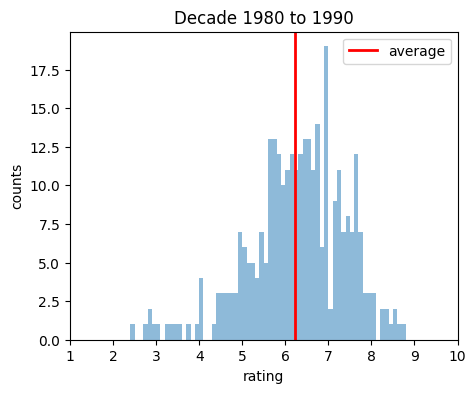

 * mysql+mysqlconnector://root:***@db
77 rows affected.


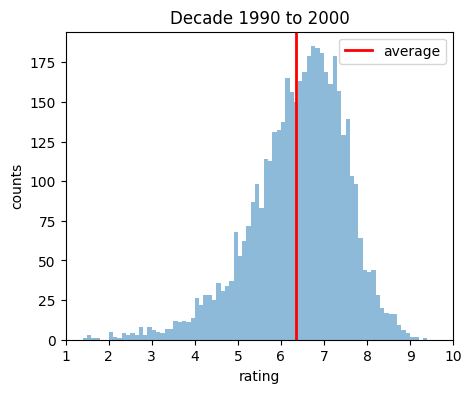

 * mysql+mysqlconnector://root:***@db
79 rows affected.


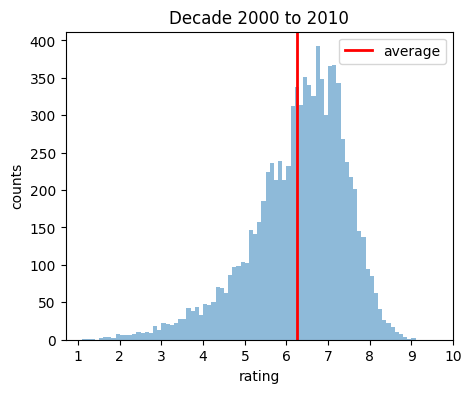

 * mysql+mysqlconnector://root:***@db
84 rows affected.


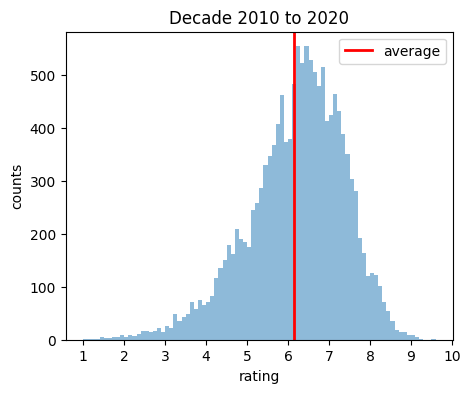

In [86]:
import numpy as np
from matplotlib.lines import Line2D
decades = np.arange(1980, 2020, 10)
mean_rating_per_decade = np.zeros(len(decades))

for idx,decade in enumerate(decades):
    query = f"""SELECT r.average_rating, COUNT(t.primary_title)
        FROM Titles t
        INNER JOIN Title_ratings r ON t.title_id = r.title_id
        WHERE (r.num_votes > 1000) AND (t.title_type = 'movie') AND (t.start_year BETWEEN {decade} AND {decade+10})
        GROUP BY r.average_rating
        ORDER BY r.average_rating;"""
    res_ = %sql $query
    
    plt.figure(figsize=(5,4))
    plt.title(f"Decade {decade} to {decade +10}")
    ratings, counts = zip(*res_)
    counts = list(counts)
    ratings = list(ratings)
    plt.bar(x=ratings, height=counts, fill=True, alpha=0.5, width=0.1, align='edge')
    average = np.sum([counts[i]*rating for i, rating in enumerate(ratings)])/np.sum(counts)
    mean_rating_per_decade[idx] = average
    plt.axvline(x=average, color="red", linewidth=2, label="average")
    plt.xticks(np.arange(1,11,1))
    plt.xlabel("rating")
    plt.ylabel("counts")
    plt.legend()
    plt.show()

Game of Thrones

 * mysql+mysqlconnector://root:***@db
73 rows affected.


Text(0, 0.5, 'Average rating')

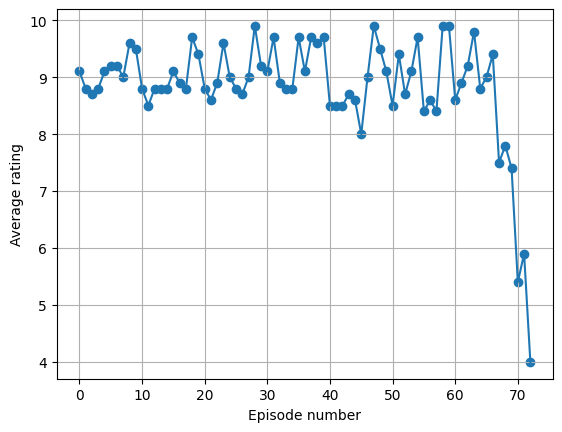

In [24]:
query =  f"""SELECT r.average_rating AS "Average Rating"
            FROM Episode_belongs_to e
            LEFT JOIN Title_ratings r ON (r.title_id = e.episode_title_id)
            WHERE e.parent_tv_show_title_id = (
                SELECT m.title_id
                FROM Titles m
                WHERE m.primary_title = "Game of Thrones"
                LIMIT 1
                )
            ORDER BY e.season_number, e.episode_number;"""

res_ = %sql $query
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(x=np.arange(0, len(res_)), y=res_)
plt.plot(np.arange(0, len(res_)), res_)
plt.grid()
plt.xlabel("Episode number")
plt.ylabel("Average rating")

#### 2: mean and std per season

In [26]:
%%sql

SELECT AVG(r.average_rating), STDDEV(r.average_rating), e.season_number
FROM Episode_belongs_to e
LEFT JOIN Title_ratings r ON (r.title_id = e.episode_title_id)
WHERE e.parent_tv_show_title_id = (
    SELECT m.title_id
    FROM Titles m
    WHERE m.primary_title = "Game of Thrones"
    LIMIT 1
    )
GROUP BY e.season_number
ORDER BY e.season_number;


 * mysql+mysqlconnector://root:***@db
8 rows affected.


AVG(r.average_rating),STDDEV(r.average_rating),season_number
9.100000095367431,0.27928484185189195,1
8.960000038146973,0.33226483855981404,2
9.05,0.3905124105321291,3
9.310000038146972,0.38327525741064195,4
8.830000019073486,0.5273518051323893,5
9.05999984741211,0.588557477116479,6
9.099999972752162,0.37416567313687316,7
6.333333412806193,1.3634107864471021,8


#### 3. 
Plot the total number of movies produced per year, divided by genre (Action, Comedy, Drama, Thriller, Fantasy), and the yearly rating average per genre.


 * mysql+mysqlconnector://root:***@db
168 rows affected.


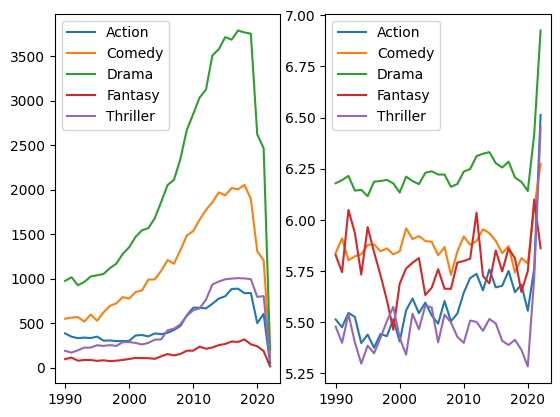

In [14]:
query= f"""
SELECT m.start_year, g.genre, COUNT(m.primary_title) AS NumMovies, AVG(r.average_rating) AS AvgRating
FROM Titles m
INNER JOIN Title_genres g ON (g.title_id = m.title_id)
INNER JOIN Title_ratings r ON (r.title_id = m.title_id)
WHERE (m.title_type = 'movie')
GROUP BY m.start_year, g.genre
HAVING g.genre IN ('Action', 'Comedy', 'Drama', 'Thriller', 'Fantasy')
ORDER BY m.start_year;"""

res_ = %sql $query
df = res_.DataFrame()

import matplotlib.pyplot as plt
import numpy as np


fig, axs = plt.subplots(nrows = 1, ncols = 2)
for genre in np.unique(df['genre'].values):
    temp = df[ df['genre'] == genre]
    axs[0].plot(temp["start_year"], temp["NumMovies"], label = f"{genre}")
    axs[1].plot(temp["start_year"], temp["AvgRating"], label = f"{genre}")
axs[0].legend()
axs[1].legend()
